# Barcelona feature-ablation study — classification

Retrains the three Barcelona classifiers (Logistic Regression, XGBoost, Random Forest) on the
**`noise_day` class** target with feature groups removed (and used alone), to measure how much
each group of features contributes. Barcelona held-out 20% only — no city transfer.

Configurations (per model):
- **full** — all 18 features (must reproduce the published baseline: LogReg 0.606 / XGB 0.741 / RF 0.749).
- **leave-one-group-out** — `-landuse`, `-centrality`, `-points`, `-distances`, `-core`.
- **single-group-only** — `only-landuse`, `only-centrality`, `only-points`, `only-distances`, `only-core`.

Every config uses a fresh `StandardScaler` on its feature subset and the **same**
`train_test_split(test_size=0.2, random_state=42)`, so the numbers are directly comparable.

## Data and libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb

In [2]:
data = pd.read_csv("../../notebooks/_elena/data/bcn_noise_class_ml_dataset.csv")
data = data.dropna(how="any").reset_index(drop=True)
y = data['noise_day'].to_numpy()
print('rows:', len(data), '| classes:', np.unique(y))

rows: 12854 | classes: [0 1 2 3 4]


## Feature groups and configurations

In [3]:
# Feature groups — the 18 model features partitioned into 5 thematic groups
FEATURE_GROUPS = {
    'core':       ['road_category', 'width'],
    'distances':  ['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary',
                   'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street'],
    'points':     ['signals', 'transport', 'pois'],
    'centrality': ['betweenness', 'closeness_global', 'closeness_400', 'straightness'],
    'landuse':    ['green', 'industrial', 'commercial'],
}
ALL_FEATURES = [f for g in FEATURE_GROUPS.values() for f in g]
assert len(ALL_FEATURES) == 18

# Build the 11 configurations: full + leave-one-group-out + single-group-only
group_order = ['landuse', 'centrality', 'points', 'distances', 'core']
configs = {'full': ALL_FEATURES}
for g in group_order:
    configs[f'-{g}'] = [f for f in ALL_FEATURES if f not in FEATURE_GROUPS[g]]
for g in group_order:
    configs[f'only-{g}'] = list(FEATURE_GROUPS[g])

for name, feats in configs.items():
    print(f'{name:16s} {len(feats):2d} features')

full             18 features
-landuse         15 features
-centrality      14 features
-points          15 features
-distances       12 features
-core            16 features
only-landuse      3 features
only-centrality   4 features
only-points       3 features
only-distances    6 features
only-core         2 features


## Run the ablation

In [4]:
def make_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000),
        'XGBoost': xgb.XGBClassifier(),
        'Random Forest': RandomForestClassifier(random_state=42),
    }

rows = []
for cfg_name, feats in configs.items():
    X_scaled = StandardScaler().fit_transform(data[feats])
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    for mname, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rows.append({
            'config': cfg_name,
            'n_features': len(feats),
            'model': mname,
            'accuracy': accuracy_score(y_te, y_pred),
            'macro_f1': f1_score(y_te, y_pred, average='macro'),
            'within_1': np.mean(np.abs(y_pred - y_te) <= 1),
        })
    print('done:', cfg_name)

results = pd.DataFrame(rows)
os.makedirs('../results', exist_ok=True)
results.to_csv('../results/ablation_classification_results.csv', index=False)
results.round(4)

done: full


done: -landuse


done: -centrality


done: -points


done: -distances


...

done: only-centrality


done: only-points


done: only-distances


done: only-core


,config,n_features,model,accuracy,macro_f1,within_1
0,full,18,Logistic Regression,0.6064,0.4288,0.9868
1,full,18,XGBoost,0.7445,0.7433,0.9953
2,full,18,Random Forest,0.7487,0.7306,0.9953
3,-landuse,15,Logistic Regression,0.6040,0.4145,0.9868
4,-landuse,15,XGBoost,0.7491,0.7438,0.9942
5,-landuse,15,Random Forest,0.7456,0.7281,0.9953
6,-centrality,14,Logistic Regression,0.5912,0.3054,0.9848
7,-centrality,14,XGBoost,0.7277,0.7019,0.9926
8,-centrality,14,Random Forest,0.7340,0.7158,0.9953
9,-points,15,Logistic Regression,0.5897,0.3293,0.9848


### Pivot — accuracy by config and model

In [5]:
acc_pivot = results.pivot(index='config', columns='model', values='accuracy')
acc_pivot = acc_pivot.reindex(list(configs.keys()))
acc_pivot.round(4)

model,Logistic Regression,Random Forest,XGBoost
config,,,
full,0.6064,0.7487,0.7445
-landuse,0.6040,0.7456,0.7491
-centrality,0.5912,0.7340,0.7277
-points,0.5897,0.7448,0.7390
-distances,0.6048,0.7238,0.7075
-core,0.6099,0.7483,0.7437
only-landuse,0.5457,0.5473,0.5500
only-centrality,0.5679,0.7013,0.6663
only-points,0.5951,0.6079,0.6021


## Figure — metrics per configuration

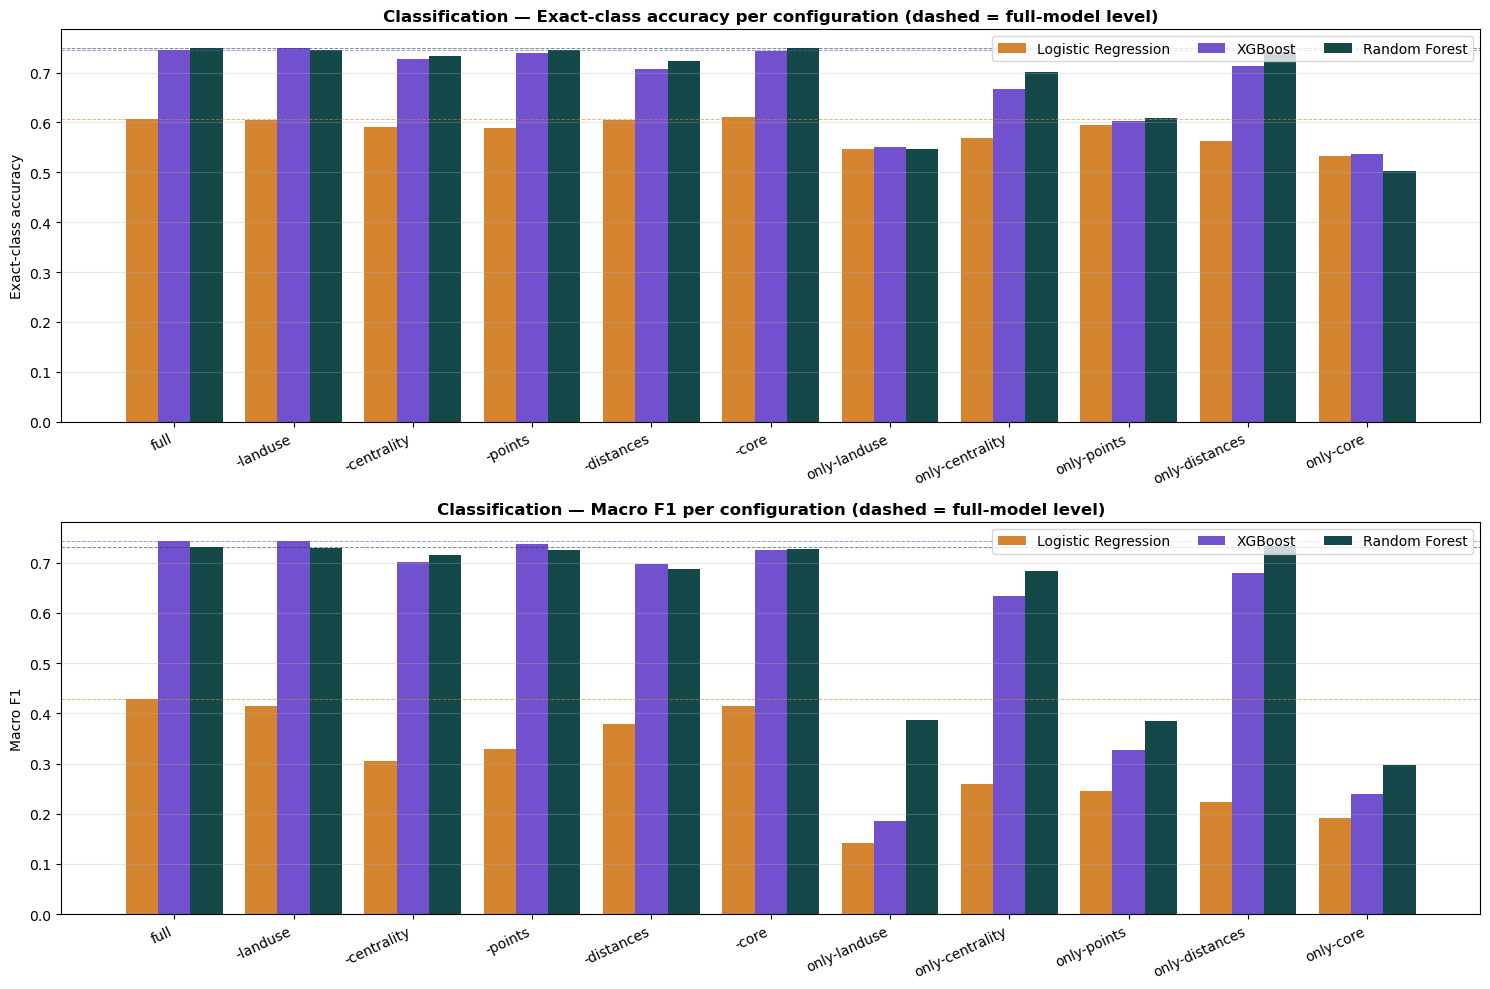

In [6]:
colors = ['#d58430', '#7251ce', '#144849']
models = ['Logistic Regression', 'XGBoost', 'Random Forest']
order = list(configs.keys())
x = np.arange(len(order)); w = 0.27

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for metric, ax, title in [('accuracy', axes[0], 'Exact-class accuracy'),
                          ('macro_f1', axes[1], 'Macro F1')]:
    piv = results.pivot(index='config', columns='model', values=metric).reindex(order)
    for i, m in enumerate(models):
        ax.bar(x + (i - 1) * w, piv[m].values, w, label=m, color=colors[i])
    # baseline line = full model, per model
    for i, m in enumerate(models):
        ax.axhline(piv.loc['full', m], ls='--', lw=0.7, color=colors[i], alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=25, ha='right')
    ax.set_title(f'Classification — {title} per configuration (dashed = full-model level)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig('../results/fig_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

The cross-task diagrams (leave-one-out importance and single-group standalone power, covering
both classification and regression) are produced by `ablation_regression.ipynb`, which runs second
and loads both result CSVs.